In [1]:
"""
CST8506 Lab 3: Convolutional Neural Networks
Author: Peng Wang
Student Number: 041107730

This lab implements a CNN model to classify handwritten digits from the MNIST dataset.
The model uses Conv2D layers, MaxPooling, and Dense layers for classification.
"""

'\nCST8506 Lab 3: Convolutional Neural Networks\nAuthor: Peng Wang\nStudent Number: 041107730\n\nThis lab implements a CNN model to classify handwritten digits from the MNIST dataset.\nThe model uses Conv2D layers, MaxPooling, and Dense layers for classification.\n'

In [2]:
# ============================================================
# 导入库
# Import Libraries
# ============================================================
# 导入标准库模块
# Import standard library modules
import os
from datetime import datetime

# 禁用 TensorFlow 警告信息（必须在导入 TensorFlow 之前设置）
# Disable TensorFlow warning messages (must be set before importing TensorFlow)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # 只显示错误 / Only show errors
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # 禁用 oneDNN 警告 / Disable oneDNN warnings

import warnings
warnings.filterwarnings('ignore')  # 禁用 Keras UserWarning / Disable Keras UserWarning

# 导入科学计算和可视化库
# Import scientific computing and visualization libraries
import numpy as np
import matplotlib.pyplot as plt

# 导入环境变量加载库
# Import environment variable loading library
from dotenv import load_dotenv

# 导入 TensorFlow 和 Keras 模块
# Import TensorFlow and Keras modules
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [3]:
# ============================================================
# 配置常量
# Configuration Constants
# ============================================================
# 随机种子：学号后三位 041107730
# Random seed: last 3 digits of student number 041107730
SEED = 730

# 每批次训练样本数量
# Number of training samples per batch
BATCH_SIZE = 128

# 训练轮数
# Number of training epochs
EPOCHS = 10

# 验证集比例（10%用于验证）
# Validation split ratio (10% for validation)
VALIDATION_SPLIT = 0.1

# 第一个卷积层的滤波器数量
# Number of filters in first convolutional layer
FIRST_CONV_FILTERS = 32

# 第二个卷积层的滤波器数量
# Number of filters in second convolutional layer
SECOND_CONV_FILTERS = 64

# 卷积核大小（3x3像素）
# Kernel size (3x3 pixels)
KERNEL_SIZE = (3, 3)

# 池化窗口大小（2x2像素）
# Pooling window size (2x2 pixels)
POOL_SIZE = (2, 2)

# 全连接层神经元数量
# Number of neurons in dense layer
DENSE_UNITS = 128

# 输出类别数量（0-9共10个数字）
# Number of output classes (0-9 digits)
NUM_CLASSES = 10

# 图像尺寸（28x28像素）
# Image size (28x28 pixels)
IMAGE_SIZE = 28

# 颜色通道数（灰度图为1，RGB图为3）
# Number of color channels (1 for grayscale, 3 for RGB)
NUM_CHANNELS = 1

In [4]:
# ============================================================
# 工具函数
# Utility Functions
# ============================================================

In [5]:
# ============================================================
# initialize_lab: 初始化实验环境，设置随机种子和输出目录
#                 Initialize lab environment, set random seed and output directory
#
# Returns:
#   output_dir: 输出目录路径
#               Output directory path
#   line_width: 分隔线宽度
#               Divider line width
# ============================================================
def initialize_lab():
    """初始化实验环境
    Initialize lab environment"""

    # 加载 .env.local 文件中的环境变量
    # Load environment variables from .env.local file
    load_dotenv('.env.local')

    # 设置随机种子以确保结果可重复
    # Set random seeds to ensure reproducible results
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    # 创建输出目录
    # Create output directory
    output_dir = 'lab3_images'
    os.makedirs(output_dir, exist_ok=True)

    # 获取学生信息和日期
    # Get student information and date
    line_width = 60
    student_name = os.getenv('NAME', 'Peng Wang')
    student_number = os.getenv('NUMBER', '041107730')
    current_date = datetime.now().strftime('%Y-%m-%d')

    print("=" * line_width)
    print("CST8506 - Lab 3: Convolutional Neural Networks")
    print(f"Author: {student_name}")
    print(f"Student Number: {student_number}")
    print(f"Date: {current_date}")
    print(f"Random Seed: {SEED}")
    print("=" * line_width)

    return output_dir, line_width

In [6]:
# ============================================================
# 步骤函数
# Step Functions
# ============================================================

In [7]:
# ============================================================
# step1_load_dataset: 加载 MNIST 数据集
#                     Load the MNIST Dataset
#
# Parameters:
#   line_width: 分隔线宽度
#               Divider line width
#
# Returns:
#   tuple: (x_train, y_train, x_test, y_test) 训练集和测试集数据
#          Training and test set data
# ============================================================
def step1_load_dataset(line_width):
    """加载 MNIST 数据集
    Load the MNIST Dataset"""

    print()
    print("=" * line_width)
    print("Step 1: Load the MNIST Dataset")
    print("=" * line_width)

    # ================================================================
    # 概念：MNIST 数据集
    # Concept: MNIST Dataset
    # ================================================================
    #
    # -------- 术语解释 / Terminology --------
    #
    # 【MNIST Modified National Institute of Standards and Technology】
    #   手写数字图像数据集，机器学习领域的 "Hello World"
    #   Handwritten digit image dataset, the "Hello World" of machine learning
    #
    # 【训练集 Training Set】
    #   用于训练模型的数据（60,000 样本）
    #   Data used to train the model (60,000 samples)
    #
    # 【测试集 Test Set】
    #   用于评估模型性能的数据（10,000 样本）
    #   Data used to evaluate model performance (10,000 samples)
    #
    # -------- 算法原理 / Algorithm --------
    #
    # 定义 / Definition:
    #   从 Keras 加载预处理好的 MNIST 数据集，自动划分训练/测试集
    #   Load preprocessed MNIST dataset from Keras, auto-split into train/test
    #
    # 公式 / Formula:
    #   无 / N/A
    #
    # 举例 / Example:
    #   x_train.shape = (60000, 28, 28) → 60000 张 28×28 灰度图
    #   y_train.shape = (60000,) → 60000 个标签 (0-9)
    #   像素值范围: 0-255
    #
    # 优点 / Advantages:
    #   - 数据集小，训练快速，适合学习和实验
    #   - 预处理完毕，可直接使用
    # ================================================================

    # 使用 Keras 加载 MNIST 数据集，返回训练集和测试集
    # Load MNIST dataset using Keras, returns training and test sets
    (x_train, y_train), (x_test, y_test) = mnist.load_data()

    print("Dataset loaded successfully.")
    print(f"Training set shape: {x_train.shape}")
    print(f"Test set shape: {x_test.shape}")

    return x_train, y_train, x_test, y_test

In [8]:
# ============================================================
# step2_print_dataset_info: 打印训练集和测试集的图像数量
#                           Print the Number of Images in Train and Test Set
#
# Parameters:
#   x_train: 训练集图像数据
#            Training set image data
#   x_test: 测试集图像数据
#           Test set image data
#   line_width: 分隔线宽度
#               Divider line width
# ============================================================
def step2_print_dataset_info(x_train, x_test, line_width):
    """打印训练集和测试集的图像数量
    Print the Number of Images in Train and Test Set"""

    print()
    print("=" * line_width)
    print("Step 2: Print the Number of Images in Train and Test Set")
    print("=" * line_width)

    # ================================================================
    # 概念：NumPy 数组形状 (Array Shape)
    # Concept: NumPy Array Shape
    # ================================================================
    #
    # -------- 术语解释 / Terminology --------
    #
    # 【shape 属性】
    #   返回数组各维度大小的元组
    #   Returns a tuple of array dimensions
    #
    # 【维度 Dimension】
    #   多维数组的各个轴，如 axis=0 是第一维
    #   Different axes of multi-dimensional array, e.g., axis=0 is first dimension
    #
    # -------- 算法原理 / Algorithm --------
    #
    # 定义 / Definition:
    #   通过 .shape 属性获取数组的维度信息
    #   Get array dimension info via .shape attribute
    #
    # 公式 / Formula:
    #   无 / N/A
    #
    # 举例 / Example:
    #   x_train.shape = (60000, 28, 28)
    #   shape[0] = 60000 (样本数)
    #   shape[1] = 28 (图像高度)
    #   shape[2] = 28 (图像宽度)
    #
    # 优点 / Advantages:
    #   - 快速了解数据结构
    #   - 验证数据加载是否正确
    # ================================================================

    # 使用 shape[0] 获取样本数量
    # Use shape[0] to get the number of samples
    num_train = x_train.shape[0]
    num_test = x_test.shape[0]

    print(f"Number of images in training set: {num_train}")
    print(f"Number of images in test set: {num_test}")
    print(f"Image dimensions: {x_train.shape[1]} x {x_train.shape[2]} pixels")

In [9]:
# ============================================================
# step3_display_first_5_images: 显示前 5 张训练图像
#                               Print First 5 Images in the Train Set
#
# Parameters:
#   x_train: 训练集图像数据
#            Training set image data
#   y_train: 训练集标签
#            Training set labels
#   output_dir: 输出目录路径
#               Output directory path
#   line_width: 分隔线宽度
#               Divider line width
# ============================================================
def step3_display_first_5_images(x_train, y_train, output_dir, line_width):
    """显示前 5 张训练图像
    Print First 5 Images in the Train Set"""

    print()
    print("=" * line_width)
    print("Step 3: Print First 5 Images in the Train Set")
    print("=" * line_width)

    # ================================================================
    # 概念：图像可视化 (Image Visualization)
    # Concept: Image Visualization
    # ================================================================
    #
    # -------- 术语解释 / Terminology --------
    #
    # 【imshow 函数】
    #   Matplotlib 函数，将数组显示为图像
    #   Matplotlib function to display array as image
    #
    # 【cmap='gray' 颜色映射】
    #   灰度映射：0=黑，255=白
    #   Grayscale colormap: 0=black, 255=white
    #
    # 【subplot 子图】
    #   在一个图形中创建多个子图
    #   Create multiple subplots in one figure
    #
    # -------- 算法原理 / Algorithm --------
    #
    # 定义 / Definition:
    #   使用 Matplotlib 将图像数组渲染为可视化图形
    #   Use Matplotlib to render image arrays as visual graphics
    #
    # 公式 / Formula:
    #   无 / N/A
    #
    # 举例 / Example:
    #   plt.subplots(1, 5) → 创建 1 行 5 列的子图
    #   axes[i].imshow(x_train[i], cmap='gray') → 显示第 i 张图
    #
    # 优点 / Advantages:
    #   - 验证数据加载是否正确
    #   - 确认标签与图像是否匹配
    # ================================================================

    # 创建 1x5 子图布局显示前 5 张图像
    # Create 1x5 subplot layout to display first 5 images
    fig, axes = plt.subplots(1, 5, figsize=(12, 3))

    for i in range(5):
        axes[i].imshow(x_train[i], cmap='gray')
        axes[i].set_title(f"Label: {y_train[i]}")
        axes[i].axis('off')

    plt.suptitle("First 5 Training Images", fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'step3_first_5_images.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print("First 5 images displayed with their labels:")
    for i in range(5):
        print(f"  Image {i+1}: Label = {y_train[i]}")
    print(f"Figure saved to: {output_dir}/step3_first_5_images.png")

In [10]:
# ============================================================
# step4_reshape_data: 重塑数据以设置通道
#                     Reshape to Set the Channel
#
# Parameters:
#   x_train: 训练集图像数据
#            Training set image data
#   x_test: 测试集图像数据
#           Test set image data
#   line_width: 分隔线宽度
#               Divider line width
#
# Returns:
#   tuple: (x_train, x_test) 重塑后的数据
#          Reshaped data
# ============================================================
def step4_reshape_data(x_train, x_test, line_width):
    """重塑数据以设置通道
    Reshape to Set the Channel"""

    print()
    print("=" * line_width)
    print("Step 4: Reshape to Set the Channel")
    print("=" * line_width)

    # ================================================================
    # 概念：张量维度重塑 (Tensor Reshaping)
    # Concept: Tensor Dimension Reshaping
    # ================================================================
    #
    # -------- 术语解释 / Terminology --------
    #
    # 【张量 Tensor】
    #   多维数组的统称，图像数据通常是 4D 张量
    #   General term for multi-dimensional arrays, image data is typically 4D tensor
    #
    # 【通道 Channel】
    #   颜色维度：灰度图=1通道，RGB图=3通道
    #   Color dimension: grayscale=1 channel, RGB=3 channels
    #
    # 【NHWC 格式】
    #   N=样本数, H=高度, W=宽度, C=通道数
    #   N=samples, H=height, W=width, C=channels
    #
    # -------- 算法原理 / Algorithm --------
    #
    # 定义 / Definition:
    #   通过 reshape 添加通道维度，满足 Conv2D 输入格式要求
    #   Add channel dimension via reshape to meet Conv2D input format
    #
    # 公式 / Formula:
    #   x.reshape(N, H, W, C) → (60000, 28, 28, 1)
    #
    # 举例 / Example:
    #   原始: (60000, 28, 28) → 重塑后: (60000, 28, 28, 1)
    #   添加的 "1" 表示单通道（灰度图）
    #
    # 优点 / Advantages:
    #   - 符合 CNN 输入格式要求 (batch, H, W, C)
    #   - 保持原始数据不变，只改变视图
    # ================================================================

    print(f"Original training shape: {x_train.shape}")
    print(f"Original test shape: {x_test.shape}")

    # 重塑：(samples, 28, 28) -> (samples, 28, 28, 1)
    # 灰度图 channel=1，RGB 图 channel=3
    # Reshape: (samples, 28, 28) -> (samples, 28, 28, 1)
    # Grayscale channel=1, RGB channel=3
    x_train = x_train.reshape(x_train.shape[0], IMAGE_SIZE, IMAGE_SIZE, NUM_CHANNELS)
    x_test = x_test.reshape(x_test.shape[0], IMAGE_SIZE, IMAGE_SIZE, NUM_CHANNELS)

    print(f"Reshaped training shape: {x_train.shape}")
    print(f"Reshaped test shape: {x_test.shape}")
    print("Channel dimension added (1 for grayscale images)")

    return x_train, x_test

In [11]:
# ============================================================
# step5_normalize_images: 归一化图像
#                         Normalize the Images
#
# Parameters:
#   x_train: 训练集图像数据
#            Training set image data
#   x_test: 测试集图像数据
#           Test set image data
#   line_width: 分隔线宽度
#               Divider line width
#
# Returns:
#   tuple: (x_train, x_test) 归一化后的数据
#          Normalized data
# ============================================================
def step5_normalize_images(x_train, x_test, line_width):
    """归一化图像
    Normalize the Images"""

    print()
    print("=" * line_width)
    print("Step 5: Normalize the Images")
    print("=" * line_width)

    print(f"Before normalization - Min: {x_train.min()}, Max: {x_train.max()}")

    # ================================================================
    # 概念：归一化 (Normalization)
    # Concept: Normalization
    # ================================================================
    #
    # -------- 术语解释 / Terminology --------
    #
    # 【归一化 Normalization】
    #   将数据缩放到固定范围（通常 0-1），使不同特征具有相同的尺度
    #   Scale data to a fixed range (usually 0-1), making different features have same scale
    #
    # 【标准化 Standardization】
    #   另一种缩放方法：(x - mean) / std，使数据均值=0，标准差=1
    #   Another scaling method: (x - mean) / std, making mean=0, std=1
    #
    # 【梯度爆炸/消失 Gradient Explosion/Vanishing】
    #   当输入值太大或太小时，梯度可能变得极大或接近 0
    #   When input values are too large or small, gradients may become huge or near 0
    #
    # -------- 算法原理 / Algorithm --------
    #
    # 定义 / Definition:
    #   将数据缩放到统一的范围（0-1 或 -1到1），使模型训练更稳定
    #   Scale data to a uniform range (0-1 or -1 to 1), making model training more stable
    #
    # 公式 / Formula:
    #   x_normalized = (x - x_min) / (x_max - x_min)
    #   对于图像：简化为 x / 255.0，因为像素范围是 [0, 255]
    #   For images: simplified to x / 255.0, since pixel range is [0, 255]
    #
    # 举例 / Example:
    #   像素值 127 -> 127 / 255 = 0.498
    #   像素值 255 -> 255 / 255 = 1.0
    #   像素值 0   -> 0 / 255 = 0.0
    #
    # 优点 / Advantages:
    #   - 防止梯度爆炸或消失，加速收敛
    #   - 确保所有特征对模型的贡献相近
    # ================================================================

    # 将像素值从 [0, 255] 归一化到 [0, 1]
    # Normalize pixel values from [0, 255] to [0, 1]
    x_train = x_train.astype('float32') / 255.0

    # 对测试集进行同样的归一化处理
    # Apply the same normalization to test set
    x_test = x_test.astype('float32') / 255.0

    print(f"After normalization - Min: {x_train.min():.4f}, Max: {x_train.max():.4f}")
    print("Normalization helps improve training stability and convergence speed.")

    return x_train, x_test

In [12]:
# ============================================================
# step6_onehot_encode_labels: 对标签进行 One-Hot 编码
#                             Apply One-Hot Encoding on the Y Values
#
# Parameters:
#   y_train: 训练集标签
#            Training set labels
#   y_test: 测试集标签
#           Test set labels
#   line_width: 分隔线宽度
#               Divider line width
#
# Returns:
#   tuple: (y_train, y_test, y_train_original, y_test_original)
#          编码后的标签和原始标签
#          Encoded labels and original labels
# ============================================================
def step6_onehot_encode_labels(y_train, y_test, line_width):
    """对标签进行 One-Hot 编码
    Apply One-Hot Encoding on the Y Values"""

    print()
    print("=" * line_width)
    print("Step 6: Apply One-Hot Encoding on the Y Values")
    print("=" * line_width)

    # 保存原始标签用于后续评估
    # Save original labels for later evaluation
    y_train_original = y_train.copy()
    y_test_original = y_test.copy()

    # ================================================================
    # 概念：One-Hot 编码
    # Concept: One-Hot Encoding
    # ================================================================
    #
    # -------- 术语解释 / Terminology --------
    #
    # 【类别标签 Categorical Label】
    #   离散的分类标识，如数字 0-9、猫/狗、正/负
    #   Discrete classification identifiers, e.g., digits 0-9, cat/dog, pos/neg
    #
    # 【稀疏表示 vs 稠密表示】
    #   整数标签 5 是稀疏的（单个数）
    #   One-hot [0,0,0,0,0,1,0,0,0,0] 是稠密的（向量）
    #   Integer label 5 is sparse (single number)
    #   One-hot [0,0,0,0,0,1,0,0,0,0] is dense (vector)
    #
    # 【to_categorical 函数】
    #   Keras 工具函数，将整数标签转为 one-hot 向量
    #   Keras utility to convert integer labels to one-hot vectors
    #
    # -------- 算法原理 / Algorithm --------
    #
    # 定义 / Definition:
    #   将离散的类别标签转换为二进制向量，只有对应类别位置为 1
    #   Convert discrete class labels to binary vectors, only the corresponding class position is 1
    #
    # 公式 / Formula:
    #   对于 N 个类别，类别 k 的 one-hot 向量为：
    #   [0, 0, ..., 1, ..., 0] (第 k 个位置为 1，其他为 0)
    #   For N classes, one-hot vector for class k is:
    #   [0, 0, ..., 1, ..., 0] (k-th position is 1, others are 0)
    #
    # 举例 / Example:
    #   10 个类别 (0-9)，数字 5 的 one-hot 编码：
    #   5 -> [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
    #   数字 0 -> [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    #   数字 9 -> [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
    #
    # 优点 / Advantages:
    #   - 避免类别之间的数值顺序关系（如 0 < 5 < 9 的误导）
    #   - 与 softmax 输出匹配，便于计算交叉熵损失
    # ================================================================

    # 将整数标签转换为 one-hot 向量
    # Convert integer labels to one-hot vectors
    y_train = to_categorical(y_train, NUM_CLASSES)

    # 对测试集标签进行同样的转换
    # Apply the same conversion to test set labels
    y_test = to_categorical(y_test, NUM_CLASSES)

    print(f"Training labels shape: {y_train.shape}")
    print(f"Test labels shape: {y_test.shape}")

    return y_train, y_test, y_train_original, y_test_original

In [13]:
# ============================================================
# step7_print_label_comparison: 打印前 5 个实例的新旧标签值
#                               Print Old and New Values for First 5 Instances
#
# Parameters:
#   y_train: 编码后的训练集标签
#            Encoded training set labels
#   y_train_original: 原始训练集标签
#                     Original training set labels
#   line_width: 分隔线宽度
#               Divider line width
# ============================================================
def step7_print_label_comparison(y_train, y_train_original, line_width):
    """打印前 5 个实例的新旧标签值
    Print Old and New Values for First 5 Instances of y_train"""

    print()
    print("=" * line_width)
    print("Step 7: Print Old and New Values for First 5 Instances of y_train")
    print("=" * line_width)

    # ================================================================
    # 概念：数据转换验证 (Data Verification)
    # Concept: Data Transformation Verification
    # ================================================================
    #
    # -------- 术语解释 / Terminology --------
    #
    # 【数据验证 Data Validation】
    #   确认数据转换正确执行，无错误或丢失
    #   Confirm data transformation executed correctly, no errors or loss
    #
    # 【对比验证 Comparison Verification】
    #   通过比较转换前后的数据来验证转换逻辑
    #   Verify transformation logic by comparing before/after data
    #
    # -------- 算法原理 / Algorithm --------
    #
    # 定义 / Definition:
    #   将原始标签与 one-hot 编码结果并排显示，验证转换正确性
    #   Display original labels alongside one-hot encoded results to verify correctness
    #
    # 公式 / Formula:
    #   无 / N/A
    #
    # 举例 / Example:
    #   原始标签: 5 → 编码后: [0,0,0,0,0,1,0,0,0,0]
    #   验证: 第 6 位（索引 5）为 1，正确
    #
    # 优点 / Advantages:
    #   - 及早发现数据处理错误
    #   - 确保标签与 softmax 输出格式匹配
    # ================================================================

    print("Comparison of original labels and one-hot encoded labels:")
    print("-" * line_width)

    for i in range(5):
        original_label = y_train_original[i]
        encoded_label = y_train[i].astype(int)
        print(f"Instance {i+1}:")
        print(f"  Original label: {original_label}")
        print(f"  One-hot encoded: {encoded_label}")

In [14]:
# ============================================================
# step8_build_cnn_model: 构建 CNN 模型
#                        Build the CNN Model
#
# Parameters:
#   line_width: 分隔线宽度
#               Divider line width
#
# Returns:
#   model: 构建好的 CNN 模型
#          Built CNN model
# ============================================================
def step8_build_cnn_model(line_width):
    """构建 CNN 模型
    Build the CNN Model"""

    print()
    print("=" * line_width)
    print("Step 8: Build the CNN Model")
    print("=" * line_width)

    # ================================================================
    # 概念：卷积神经网络 (CNN)
    # Concept: Convolutional Neural Network
    # ================================================================
    #
    # -------- 术语解释 / Terminology --------
    #
    # 【卷积层 Conv2D】
    #   用滤波器在图像上滑动，提取局部特征（边缘、纹理）
    #   Slide filters over image to extract local features (edges, textures)
    #
    # 【ReLU 激活函数】
    #   公式：f(x) = max(0, x)，引入非线性
    #   Formula: f(x) = max(0, x), introduces non-linearity
    #
    # 【池化层 MaxPooling2D】
    #   取局部最大值，压缩特征图尺寸
    #   Take local max value, compress feature map size
    #
    # 【Softmax 激活函数】
    #   公式：P(y=k|x) = e^(z_k) / Σ e^(z_j)
    #   将输出转换为概率分布
    #   Formula: P(y=k|x) = e^(z_k) / Σ e^(z_j)
    #   Convert outputs to probability distribution
    #
    # -------- 算法原理 / Algorithm --------
    #
    # 定义 / Definition:
    #   通过卷积层提取图像空间特征，通过池化层压缩维度，最后全连接分类
    #   Extract spatial features via Conv layers, compress via Pooling, Dense for classification
    #
    # 公式 / Formula:
    #   卷积: output[i,j] = Σ (input[i+m, j+n] × kernel[m,n]) + bias
    #   池化: output = max(region)
    #
    # 举例 / Example:
    #   输入: 28×28×1 → Conv(32) → Pool → 14×14×32
    #                 → Conv(64) → Pool → 7×7×64
    #                 → Flatten → 3136 → Dense(128) → Dense(10)
    #
    # 优点 / Advantages:
    #   - 参数共享，大大减少参数数量
    #   - 平移不变性，对位置不敏感
    # ================================================================

    # 创建 Sequential 模型，按顺序堆叠各层
    # Create Sequential model, stacking layers in order
    model = Sequential([
        # 第一个卷积层：32 个 3x3 滤波器，ReLU 激活，same 填充保持尺寸
        # First Conv layer: 32 3x3 filters, ReLU activation, same padding keeps size
        Conv2D(FIRST_CONV_FILTERS, KERNEL_SIZE, activation='relu', padding='same',
               input_shape=(IMAGE_SIZE, IMAGE_SIZE, NUM_CHANNELS)),

        # 第一个池化层：2x2 最大池化，维度减半 (28x28 -> 14x14)
        # First pooling: 2x2 max pooling, halves dimensions (28x28 -> 14x14)
        MaxPooling2D(pool_size=POOL_SIZE),

        # 第二个卷积层：64 个滤波器学习更复杂的特征
        # Second Conv layer: 64 filters learn more complex features
        Conv2D(SECOND_CONV_FILTERS, KERNEL_SIZE, activation='relu', padding='same'),

        # 第二个池化层：维度再次减半 (14x14 -> 7x7)
        # Second pooling: halves dimensions again (14x14 -> 7x7)
        MaxPooling2D(pool_size=POOL_SIZE),

        # 展平层：将 2D 特征图 (7x7x64) 转换为 1D 向量 (3136)
        # Flatten: converts 2D feature maps (7x7x64) to 1D vector (3136)
        Flatten(),

        # 全连接层：128 神经元，学习特征的非线性组合
        # Dense layer: 128 neurons, learns non-linear feature combinations
        Dense(DENSE_UNITS, activation='relu'),

        # 输出层：10 个神经元，softmax 输出概率分布
        # Output layer: 10 neurons, softmax outputs probability distribution
        Dense(NUM_CLASSES, activation='softmax')
    ])

    print("Model Architecture: Input -> Conv -> MaxPool -> Conv -> MaxPool -> Flatten -> Dense -> Dense")
    print()
    print("Layer Parameters:")
    print(f"  Conv2D Layer 1: {FIRST_CONV_FILTERS} filters, kernel_size={KERNEL_SIZE}, "
          f"activation='relu', padding='same'")
    print(f"  MaxPooling2D: pool_size={POOL_SIZE}")
    print(f"  Conv2D Layer 2: {SECOND_CONV_FILTERS} filters, kernel_size={KERNEL_SIZE}, "
          f"activation='relu', padding='same'")
    print(f"  MaxPooling2D: pool_size={POOL_SIZE}")
    print(f"  Flatten: Converts 2D feature maps to 1D vector")
    print(f"  Dense Layer 1: {DENSE_UNITS} units, activation='relu'")
    print(f"  Dense Layer 2 (Output): {NUM_CLASSES} units, activation='softmax'")

    return model

In [15]:
# ============================================================
# step9_compile_model: 编译模型
#                      Compile the Model
#
# Parameters:
#   model: CNN 模型
#          CNN model
#   line_width: 分隔线宽度
#               Divider line width
# ============================================================
def step9_compile_model(model, line_width):
    """编译模型
    Compile the Model"""

    print()
    print("=" * line_width)
    print("Step 9: Compile the Model")
    print("=" * line_width)

    # ================================================================
    # 概念：模型编译 (Model Compilation)
    # Concept: Model Compilation
    # ================================================================
    #
    # -------- 术语解释 / Terminology --------
    #
    # 【Adam 优化器】
    #   自适应学习率优化算法，结合 Momentum 和 RMSprop 优点
    #   Adaptive learning rate optimizer, combining Momentum and RMSprop
    #
    # 【交叉熵 Cross-Entropy】
    #   多分类任务的损失函数，衡量预测与真实分布的差距
    #   Loss function for multi-class, measures difference between predicted and true distributions
    #
    # -------- 算法原理 / Algorithm --------
    #
    # 定义 / Definition:
    #   配置模型的优化器、损失函数和评估指标，使模型可训练
    #   Configure optimizer, loss function and metrics to make model trainable
    #
    # 公式 / Formula:
    #   交叉熵: L = -Σ y_true × log(y_pred)
    #
    # 举例 / Example:
    #   真实: [0,0,1], 预测: [0.1,0.2,0.7]
    #   L = -log(0.7) = 0.36 (损失较小，预测较准)
    #
    # 优点 / Advantages:
    #   - Adam 自动调整学习率，收敛快
    #   - 交叉熵对错误预测惩罚大
    # ================================================================

    # 编译模型：配置优化器、损失函数和评估指标
    # Compile model: configure optimizer, loss function and evaluation metrics
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print("Model compiled with:")
    print("  optimizer='adam' - Adaptive learning rate optimization algorithm")
    print("  loss='categorical_crossentropy' - Multi-class cross-entropy loss function")
    print("  metrics=['accuracy'] - Classification accuracy")

In [16]:
# ============================================================
# step10_print_model_summary: 打印模型摘要
#                             Print the Model Summary
#
# Parameters:
#   model: CNN 模型
#          CNN model
#   line_width: 分隔线宽度
#               Divider line width
# ============================================================
def step10_print_model_summary(model, line_width):
    """打印模型摘要
    Print the Model Summary"""

    print()
    print("=" * line_width)
    print("Step 10: Print the Model Summary")
    print("=" * line_width)

    # ================================================================
    # 概念：模型摘要 (Model Summary)
    # Concept: Model Summary
    # ================================================================
    #
    # -------- 术语解释 / Terminology --------
    #
    # 【层 Layer】
    #   神经网络的基本构建单元
    #   Basic building block of neural network
    #
    # 【参数量 Parameters】
    #   模型中的可训练权重数量
    #   Number of trainable weights in model
    #
    # 【输出形状 Output Shape】
    #   每层输出张量的维度
    #   Dimensions of output tensor from each layer
    #
    # -------- 算法原理 / Algorithm --------
    #
    # 定义 / Definition:
    #   显示模型每层的配置、输出形状和参数数量
    #   Display each layer's configuration, output shape and parameter count
    #
    # 公式 / Formula:
    #   Conv2D 参数 = (kernel_h × kernel_w × input_channels + 1) × filters
    #
    # 举例 / Example:
    #   Conv2D(32, 3×3, input 28×28×1): (3×3×1+1)×32 = 320 参数
    #   Dense(10, input 128): (128+1)×10 = 1290 参数
    #
    # 优点 / Advantages:
    #   - 快速了解模型结构
    #   - 估算模型内存需求
    # ================================================================

    model.summary()

In [17]:
# ============================================================
# step11_train_model: 训练模型
#                     Fit the Model
#
# Parameters:
#   model: CNN 模型
#          CNN model
#   x_train: 训练集图像数据
#            Training set image data
#   y_train: 训练集标签
#            Training set labels
#   output_dir: 输出目录路径
#               Output directory path
#   line_width: 分隔线宽度
#               Divider line width
#
# Returns:
#   history: 训练历史记录
#            Training history
# ============================================================
def step11_train_model(model, x_train, y_train, output_dir, line_width):
    """训练模型
    Fit the Model"""

    print()
    print("=" * line_width)
    print("Step 11: Fit the Model")
    print("=" * line_width)

    # ================================================================
    # 概念：模型训练 (Model Training)
    # Concept: Model Training
    # ================================================================
    #
    # -------- 术语解释 / Terminology --------
    #
    # 【Epoch 轮】
    #   模型遍历完整训练集一次
    #   One complete pass through entire training dataset
    #
    # 【Batch 批次】
    #   每次梯度更新使用的样本数量
    #   Number of samples used for each gradient update
    #
    # 【Validation Split 验证集划分】
    #   从训练集划分部分用于验证
    #   Split portion of training set for validation
    #
    # -------- 算法原理 / Algorithm --------
    #
    # 定义 / Definition:
    #   通过前向传播、损失计算、反向传播迭代更新模型权重
    #   Iteratively update model weights via forward pass, loss, backprop
    #
    # 公式 / Formula:
    #   权重更新: w = w - learning_rate × gradient
    #
    # 举例 / Example:
    #   54000 训练样本 (90%), batch=128 → 每个 epoch 约 422 次更新
    #   10 epochs → 共约 4220 次权重更新
    #
    # 优点 / Advantages:
    #   - 验证集可监控过拟合
    #   - 记录 history 可绘制学习曲线
    # ================================================================

    print(f"Training Parameters:")
    print(f"  batch_size={BATCH_SIZE} - Number of samples per gradient update")
    print(f"  epochs={EPOCHS} - Number of training iterations")
    print(f"  validation_split={VALIDATION_SPLIT} - Fraction of data for validation")
    print()

    # 训练模型并记录历史
    # Train the model and record history
    # verbose=2: 每个 epoch 结束时显示一行（无进度条）
    # verbose=2: Show one line per epoch (no progress bar)
    history = model.fit(
        x_train, y_train,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_split=VALIDATION_SPLIT,
        verbose=2
    )

    # 绘制训练历史曲线
    # Plot training history curves
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history['accuracy'], label='Training Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0].set_title('Model Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history.history['loss'], label='Training Loss')
    axes[1].plot(history.history['val_loss'], label='Validation Loss')
    axes[1].set_title('Model Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'step11_training_history.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nTraining history saved to: {output_dir}/step11_training_history.png")

    return history

In [18]:
# ============================================================
# step12_predict_test_data: 预测测试数据
#                           Predict for the Test Data
#
# Parameters:
#   model: CNN 模型
#          CNN model
#   x_test: 测试集图像数据
#           Test set image data
#   line_width: 分隔线宽度
#               Divider line width
#
# Returns:
#   predictions: 预测结果
#                Prediction results
# ============================================================
def step12_predict_test_data(model, x_test, line_width):
    """预测测试数据
    Predict for the Test Data"""

    print()
    print("=" * line_width)
    print("Step 12: Predict for the Test Data")
    print("=" * line_width)

    # ================================================================
    # 概念：模型预测 (Model Prediction)
    # Concept: Model Prediction
    # ================================================================
    #
    # -------- 术语解释 / Terminology --------
    #
    # 【predict 函数】
    #   对输入进行前向传播，输出概率分布
    #   Forward pass on input, outputs probability distribution
    #
    # 【概率分布 Probability Distribution】
    #   每个类别的预测概率，总和为 1
    #   Predicted probability for each class, sums to 1
    #
    # -------- 算法原理 / Algorithm --------
    #
    # 定义 / Definition:
    #   将测试数据通过训练好的模型，获取每个样本的类别概率
    #   Pass test data through trained model to get class probabilities
    #
    # 公式 / Formula:
    #   输出 = softmax(最后一层线性输出)
    #
    # 举例 / Example:
    #   输入: (10000, 28, 28, 1) → 输出: (10000, 10)
    #   单样本: [0.01, 0.02, ..., 0.89, ...] → 预测为 5
    #
    # 优点 / Advantages:
    #   - 获取概率而非硬标签，可评估置信度
    #   - 支持批量预测，效率高
    # ================================================================

    predictions = model.predict(x_test, verbose=0)

    print(f"Predictions shape: {predictions.shape}")
    print(f"Each prediction is a probability distribution over {NUM_CLASSES} classes")

    return predictions

In [19]:
# ============================================================
# step13_print_accuracy: 打印模型准确率
#                        Print the Accuracy of the Model
#
# Parameters:
#   model: CNN 模型
#          CNN model
#   x_test: 测试集图像数据
#           Test set image data
#   y_test: 测试集标签
#           Test set labels
#   line_width: 分隔线宽度
#               Divider line width
# ============================================================
def step13_print_accuracy(model, x_test, y_test, line_width):
    """打印模型准确率
    Print the Accuracy of the Model"""

    print()
    print("=" * line_width)
    print("Step 13: Print the Accuracy of the Model")
    print("=" * line_width)

    # ================================================================
    # 概念：模型评估 (Model Evaluation)
    # Concept: Model Evaluation
    # ================================================================
    #
    # -------- 术语解释 / Terminology --------
    #
    # 【准确率 Accuracy】
    #   正确预测数 / 总样本数
    #   Number of correct predictions / Total samples
    #
    # 【测试损失 Test Loss】
    #   测试集上的平均交叉熵损失
    #   Average cross-entropy loss on test set
    #
    # -------- 算法原理 / Algorithm --------
    #
    # 定义 / Definition:
    #   使用模型从未见过的测试集评估泛化性能
    #   Evaluate generalization using unseen test set
    #
    # 公式 / Formula:
    #   Accuracy = Σ(pred == true) / N
    #
    # 举例 / Example:
    #   正确 9850，总数 10000 → Accuracy = 98.5%
    #
    # 优点 / Advantages:
    #   - 测试集评估反映真实性能
    #   - 可与验证集对比判断过拟合
    # ================================================================

    test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

In [20]:
# ============================================================
# step14_find_highest_probability: 找到每行最高概率的索引
#                                  Find the Index of the Highest Probability for Each Row
#
# Parameters:
#   predictions: 预测结果
#                Prediction results
#   line_width: 分隔线宽度
#               Divider line width
#
# Returns:
#   tuple: (predicted_labels, highest_probs) 预测标签和最高概率
#          Predicted labels and highest probabilities
# ============================================================
def step14_find_highest_probability(predictions, line_width):
    """找到每行最高概率的索引
    Find the Index of the Highest Probability for Each Row"""

    print()
    print("=" * line_width)
    print("Step 14: Find the Index of the Highest Probability for Each Row")
    print("=" * line_width)

    # ================================================================
    # 概念：Argmax 操作 (Argmax Operation)
    # Concept: Argmax Operation
    # ================================================================
    #
    # -------- 术语解释 / Terminology --------
    #
    # 【argmax 函数】
    #   返回数组中最大值的索引位置
    #   Returns index position of maximum value
    #
    # 【axis 参数】
    #   axis=1 表示沿行方向操作
    #   axis=1 means operate along row direction
    #
    # -------- 算法原理 / Algorithm --------
    #
    # 定义 / Definition:
    #   从概率分布中选择概率最高的类别作为预测结果
    #   Select class with highest probability as prediction
    #
    # 公式 / Formula:
    #   predicted_class = argmax(probabilities)
    #
    # 举例 / Example:
    #   [0.01, 0.02, 0.01, 0.01, 0.01, 0.01, 0.01, 0.91, 0.01, 0.00]
    #   argmax = 7 → 预测为数字 7
    #
    # 优点 / Advantages:
    #   - 简单高效的决策规则
    #   - 向量化操作，批量计算快
    # ================================================================

    # 使用 argmax 找到概率最高的类别索引
    # Use argmax to find the index of highest probability class
    predicted_labels = np.argmax(predictions, axis=1)
    highest_probs = np.max(predictions, axis=1)

    print("Method: np.argmax(predictions, axis=1)")
    print(f"Predicted labels shape: {predicted_labels.shape}")
    print("Example: [0.0, 0.0, 0.01, 0.0, 0.0, 0.0, 0.0, 0.99, 0.0, 0.0] -> Predicted digit: 7")

    return predicted_labels, highest_probs

In [21]:
# ============================================================
# step15_print_first_20_results: 打印前 20 个预测结果
#                                Print the Results for the First 20 Instances
#
# Parameters:
#   predicted_labels: 预测标签
#                     Predicted labels
#   highest_probs: 最高概率
#                  Highest probabilities
#   y_test_original: 原始测试集标签
#                    Original test set labels
#   line_width: 分隔线宽度
#               Divider line width
# ============================================================
def step15_print_first_20_results(predicted_labels, highest_probs, y_test_original, line_width):
    """打印前 20 个预测结果
    Print the Results for the First 20 Instances"""

    print()
    print("=" * line_width)
    print("Step 15: Print the Results for the First 20 Instances")
    print("=" * line_width)

    # ================================================================
    # 概念：预测结果分析 (Result Analysis)
    # Concept: Prediction Result Analysis
    # ================================================================
    #
    # -------- 术语解释 / Terminology --------
    #
    # 【置信度 Confidence】
    #   模型对预测的确信程度（概率值）
    #   Model's certainty about prediction (probability value)
    #
    # 【正确/错误预测】
    #   OK: 预测 = 真实, X: 预测 ≠ 真实
    #   OK: pred = true, X: pred ≠ true
    #
    # -------- 算法原理 / Algorithm --------
    #
    # 定义 / Definition:
    #   展示预测结果与真实标签的对比，分析模型表现
    #   Display prediction vs true label comparison to analyze model
    #
    # 公式 / Formula:
    #   无 / N/A
    #
    # 举例 / Example:
    #   [0.9876543] | 7 | 7 OK  → 高置信度正确预测
    #   [0.6543210] | 3 | 8 X   → 中置信度错误预测
    #
    # 优点 / Advantages:
    #   - 直观了解模型预测质量
    #   - 发现高置信度错误（过度自信）
    # ================================================================

    print()
    print(f"{'Highest Probability':<22} | {'Predicted Digit':<15} | {'Actual Digit':<12}")
    print("-" * line_width)

    for i in range(20):
        prob = highest_probs[i]
        pred = predicted_labels[i]
        actual = y_test_original[i]
        match = "OK" if pred == actual else "X"
        print(f"[{prob:.7f}]            | {pred:<15} | {actual:<12} {match}")

In [22]:
# ============================================================
# step16_print_misclassified: 打印所有错误分类的结果
#                             Print the Results for All Misclassified Instances
#
# Parameters:
#   x_test: 测试集图像数据
#           Test set image data
#   predicted_labels: 预测标签
#                     Predicted labels
#   highest_probs: 最高概率
#                  Highest probabilities
#   y_test_original: 原始测试集标签
#                    Original test set labels
#   output_dir: 输出目录路径
#               Output directory path
#   line_width: 分隔线宽度
#               Divider line width
# ============================================================
def step16_print_misclassified(x_test, predicted_labels, highest_probs, y_test_original, output_dir, line_width):
    """打印所有错误分类的结果
    Print the Results for All Misclassified Instances"""

    print()
    print("=" * line_width)
    print("Step 16: Print the Results for All Misclassified Instances")
    print("=" * line_width)

    # ================================================================
    # 概念：错误分析 (Error Analysis)
    # Concept: Error Analysis
    # ================================================================
    #
    # -------- 术语解释 / Terminology --------
    #
    # 【错误分类 Misclassification】
    #   模型预测的类别与真实类别不一致
    #   Model's predicted class differs from true class
    #
    # 【错误率 Error Rate】
    #   错误分类数 / 总样本数 = 1 - 准确率
    #   Misclassified / Total = 1 - Accuracy
    #
    # -------- 算法原理 / Algorithm --------
    #
    # 定义 / Definition:
    #   分析模型预测错误的样本，识别失败模式
    #   Analyze incorrectly predicted samples to identify failure patterns
    #
    # 公式 / Formula:
    #   错误样本 = np.where(predicted != actual)
    #
    # 举例 / Example:
    #   150/10000 错误 → 错误率 1.5%
    #   常见混淆：4↔9, 3↔8, 7↔1
    #
    # 优点 / Advantages:
    #   - 识别模型弱点
    #   - 指导数据增强和模型改进
    # ================================================================

    # 找到所有预测错误的实例
    # Find all incorrectly predicted instances
    misclassified_indices = np.where(predicted_labels != y_test_original)[0]
    num_misclassified = len(misclassified_indices)

    print(f"Total misclassified: {num_misclassified} out of {len(y_test_original)}")
    print(f"Misclassification rate: {num_misclassified/len(y_test_original)*100:.2f}%")
    print()

    display_count = min(20, num_misclassified)
    print(f"First {display_count} misclassified instances:")
    print()
    print(f"{'Highest Probability':<22} | {'Predicted Digit':<15} | {'Actual Digit':<12}")
    print("-" * line_width)

    for i in range(display_count):
        idx = misclassified_indices[i]
        prob = highest_probs[idx]
        pred = predicted_labels[idx]
        actual = y_test_original[idx]
        print(f"[{prob:.7f}]            | {pred:<15} | {actual:<12}")

    # 可视化部分错误分类的图像
    # Visualize some misclassified images
    num_to_plot = min(10, num_misclassified)
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()

    for i in range(num_to_plot):
        idx = misclassified_indices[i]
        img = x_test[idx].reshape(IMAGE_SIZE, IMAGE_SIZE)
        pred = predicted_labels[idx]
        actual = y_test_original[idx]
        prob = highest_probs[idx]

        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"Pred: {pred} ({prob:.2%})\nActual: {actual}")
        axes[i].axis('off')

    for i in range(num_to_plot, len(axes)):
        axes[i].axis('off')

    plt.suptitle("Misclassified Images", fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'step16_misclassified_images.png'), dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nMisclassified images saved to: {output_dir}/step16_misclassified_images.png")

CST8506 - Lab 3: Convolutional Neural Networks
Author: Peng Wang
Student Number: 041107730
Date: 2026-02-09
Random Seed: 730

Step 1: Load the MNIST Dataset
Dataset loaded successfully.
Training set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28)

Step 2: Print the Number of Images in Train and Test Set
Number of images in training set: 60000
Number of images in test set: 10000
Image dimensions: 28 x 28 pixels

Step 3: Print First 5 Images in the Train Set


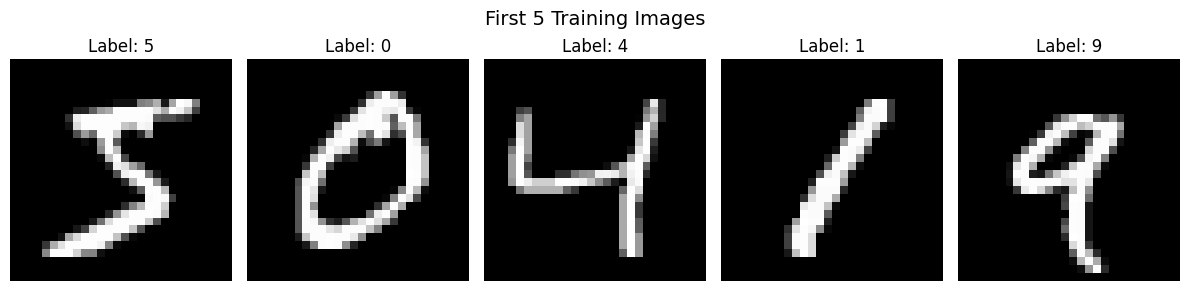

First 5 images displayed with their labels:
  Image 1: Label = 5
  Image 2: Label = 0
  Image 3: Label = 4
  Image 4: Label = 1
  Image 5: Label = 9
Figure saved to: lab3_images/step3_first_5_images.png

Step 4: Reshape to Set the Channel
Original training shape: (60000, 28, 28)
Original test shape: (10000, 28, 28)
Reshaped training shape: (60000, 28, 28, 1)
Reshaped test shape: (10000, 28, 28, 1)
Channel dimension added (1 for grayscale images)

Step 5: Normalize the Images
Before normalization - Min: 0, Max: 255
After normalization - Min: 0.0000, Max: 1.0000
Normalization helps improve training stability and convergence speed.

Step 6: Apply One-Hot Encoding on the Y Values
Training labels shape: (60000, 10)
Test labels shape: (10000, 10)

Step 7: Print Old and New Values for First 5 Instances of y_train
Comparison of original labels and one-hot encoded labels:
------------------------------------------------------------
Instance 1:
  Original label: 5
  One-hot encoded: [0 0 0 0 0 1

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)


Step 11: Fit the Model
Training Parameters:
  batch_size=128 - Number of samples per gradient update
  epochs=10 - Number of training iterations
  validation_split=0.1 - Fraction of data for validation

Epoch 1/10
422/422 - 13s - 31ms/step - accuracy: 0.9358 - loss: 0.2093 - val_accuracy: 0.9825 - val_loss: 0.0634
Epoch 2/10
422/422 - 11s - 26ms/step - accuracy: 0.9831 - loss: 0.0558 - val_accuracy: 0.9878 - val_loss: 0.0459
Epoch 3/10
422/422 - 11s - 26ms/step - accuracy: 0.9883 - loss: 0.0377 - val_accuracy: 0.9885 - val_loss: 0.0429
Epoch 4/10
422/422 - 11s - 27ms/step - accuracy: 0.9915 - loss: 0.0275 - val_accuracy: 0.9895 - val_loss: 0.0420
Epoch 5/10
422/422 - 11s - 26ms/step - accuracy: 0.9940 - loss: 0.0202 - val_accuracy: 0.9882 - val_loss: 0.0427
Epoch 6/10
422/422 - 11s - 27ms/step - accuracy: 0.9954 - loss: 0.0157 - val_accuracy: 0.9885 - val_loss: 0.0451
Epoch 7/10
422/422 - 11s - 26ms/step - accuracy: 0.9957 - loss: 0.0138 - val_accuracy: 0.9885 - val_loss: 0.0489
Epoch

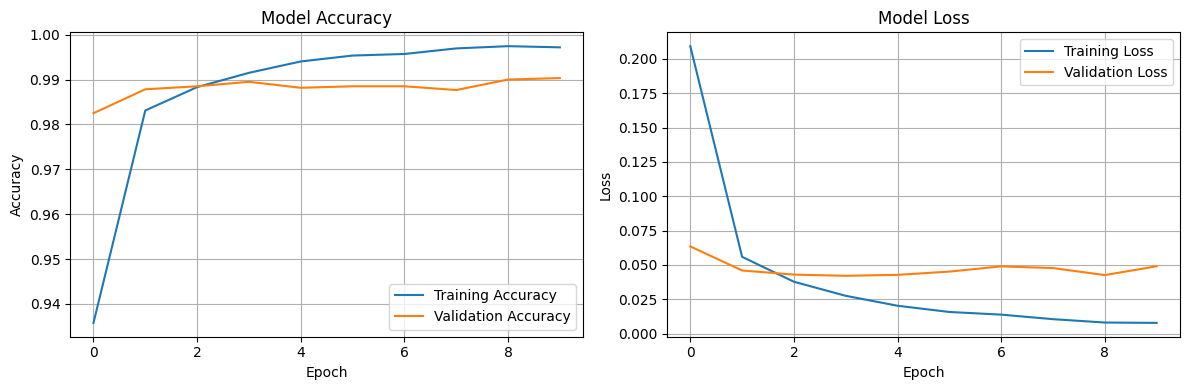


Training history saved to: lab3_images/step11_training_history.png

Step 12: Predict for the Test Data
Predictions shape: (10000, 10)
Each prediction is a probability distribution over 10 classes

Step 13: Print the Accuracy of the Model
Test Loss: 0.0373
Test Accuracy: 0.9892 (98.92%)

Step 14: Find the Index of the Highest Probability for Each Row
Method: np.argmax(predictions, axis=1)
Predicted labels shape: (10000,)
Example: [0.0, 0.0, 0.01, 0.0, 0.0, 0.0, 0.0, 0.99, 0.0, 0.0] -> Predicted digit: 7

Step 15: Print the Results for the First 20 Instances

Highest Probability    | Predicted Digit | Actual Digit
------------------------------------------------------------
[0.9999999]            | 7               | 7            OK
[1.0000000]            | 2               | 2            OK
[0.9999996]            | 1               | 1            OK
[1.0000000]            | 0               | 0            OK
[0.9999937]            | 4               | 4            OK
[1.0000000]            

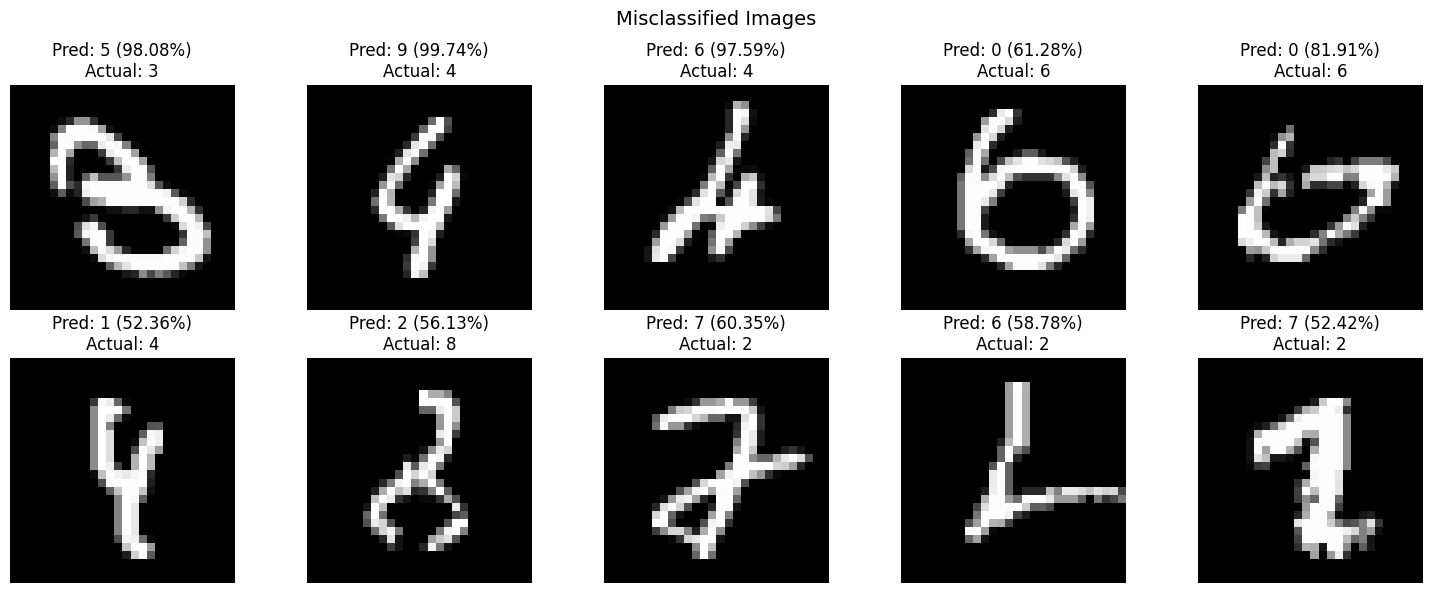


Misclassified images saved to: lab3_images/step16_misclassified_images.png


In [23]:
# ============================================================
# 主程序入口
# Main Programme Entry
# ============================================================
def main():
    # ============================================================
    # 步骤 0：实验初始化
    # Step 0: Lab Initialization
    # ============================================================
    output_dir, line_width = initialize_lab()

    # ============================================================
    # 步骤 1：加载数据集
    # Step 1: Load the Dataset
    # ============================================================
    x_train, y_train, x_test, y_test = step1_load_dataset(line_width)

    # ============================================================
    # 步骤 2：打印训练集和测试集的图像数量
    # Step 2: Print the Number of Images in Train and Test Set
    # ============================================================
    step2_print_dataset_info(x_train, x_test, line_width)

    # ============================================================
    # 步骤 3：显示前 5 张训练图像
    # Step 3: Print First 5 Images in the Train Set
    # ============================================================
    step3_display_first_5_images(x_train, y_train, output_dir, line_width)

    # ============================================================
    # 步骤 4：重塑数据以设置通道
    # Step 4: Reshape to Set the Channel
    # ============================================================
    x_train, x_test = step4_reshape_data(x_train, x_test, line_width)

    # ============================================================
    # 步骤 5：归一化图像
    # Step 5: Normalize the Images
    # ============================================================
    x_train, x_test = step5_normalize_images(x_train, x_test, line_width)

    # ============================================================
    # 步骤 6：对标签进行 One-Hot 编码
    # Step 6: Apply One-Hot Encoding on the Y Values
    # ============================================================
    y_train, y_test, y_train_original, y_test_original = step6_onehot_encode_labels(y_train, y_test, line_width)

    # ============================================================
    # 步骤 7：打印前 5 个实例的新旧标签值
    # Step 7: Print Old and New Values for First 5 Instances of y_train
    # ============================================================
    step7_print_label_comparison(y_train, y_train_original, line_width)

    # ============================================================
    # 步骤 8：构建 CNN 模型
    # Step 8: Build the CNN Model
    # ============================================================
    model = step8_build_cnn_model(line_width)

    # ============================================================
    # 步骤 9：编译模型
    # Step 9: Compile the Model
    # ============================================================
    step9_compile_model(model, line_width)

    # ============================================================
    # 步骤 10：打印模型摘要
    # Step 10: Print the Model Summary
    # ============================================================
    step10_print_model_summary(model, line_width)

    # ============================================================
    # 步骤 11：训练模型
    # Step 11: Fit the Model
    # ============================================================
    history = step11_train_model(model, x_train, y_train, output_dir, line_width)

    # ============================================================
    # 步骤 12：预测测试数据
    # Step 12: Predict for the Test Data
    # ============================================================
    predictions = step12_predict_test_data(model, x_test, line_width)

    # ============================================================
    # 步骤 13：打印模型准确率
    # Step 13: Print the Accuracy of the Model
    # ============================================================
    step13_print_accuracy(model, x_test, y_test, line_width)

    # ============================================================
    # 步骤 14：找到每行最高概率的索引
    # Step 14: Find the Index of the Highest Probability for Each Row
    # ============================================================
    predicted_labels, highest_probs = step14_find_highest_probability(predictions, line_width)

    # ============================================================
    # 步骤 15：打印前 20 个预测结果
    # Step 15: Print the Results for the First 20 Instances
    # ============================================================
    step15_print_first_20_results(predicted_labels, highest_probs, y_test_original, line_width)

    # ============================================================
    # 步骤 16：打印所有错误分类的结果
    # Step 16: Print the Results for All Misclassified Instances
    # ============================================================
    step16_print_misclassified(x_test, predicted_labels, highest_probs, y_test_original, output_dir, line_width)


if __name__ == "__main__":
    main()